# 中文文本K-means聚类（教学版·独立运行）

本Notebook不调用外部Python程序。文本预处理与层次聚类Notebook保持一致：文件读取 → Jieba分词与词性筛选 → 停用词、数字、英文字母和同义词处理 → 高频变量筛选 → 相对频率或TF-IDF矩阵 → K-means聚类 → 古典多维尺度分析（Classical MDS）散点图。

请从上到下依次运行。各通用步骤放在独立单元格中，便于在其他文本分析中复用。


## 0. 安装所需软件包

第一次运行时，请删除下一行开头的 # 后执行。安装完成后如有必要，请重新启动内核。


In [41]:
# %pip install numpy scipy matplotlib pandas jieba scikit-learn


## 1. 全部参数设置

所有可选参数集中在这里。

重要说明：

- **CLUSTER_MATRIX_TYPE** 指定K-means使用相对频率或TF-IDF。
- **KMEANS_DISTANCE** 指定 euclidean 或 hellinger。
- 选择 euclidean 时，K-means直接使用CLUSTER_MATRIX_TYPE指定的矩阵。
- 选择 hellinger 时，程序固定使用相对频率的Hellinger坐标 sqrt(相对频率)/sqrt(2)，再执行欧氏K-means。
- Classical MDS散点图使用与K-means相同的距离，点的颜色表示K-means聚类结果。


In [42]:
from pathlib import Path

# ==================== 输入与输出 ====================
INPUT_DIR = Path(r"C:\Users\mzjin\OneDrive\Desktop\讲座课件\zhuowen\c_text")
OUTPUT_DIR = Path(r"C:\temp\kmeans_clustering_results")
ENCODING = "utf-8-sig"
READ_RECURSIVELY = True

# ==================== 分词与词语处理 ====================
# Jieba词性前缀：n=名词，v=动词，a=形容词；空列表 [] 表示保留全部词性。
POS_PREFIXES = ["n"] #, "v", "a"]
STOPWORDS = {"的", "了", "和", "是", "在", "也", "有", "与", "及", "等", "一个",
            "真纪","人","时","地方"}
# 可另外指定UTF-8停用词文件，每行一个词；不使用时设为None。
STOPWORD_FILE = None
REMOVE_DIGITS = True
REMOVE_LATIN = True
MIN_TOKEN_LENGTH = 1
CUSTOM_WORDS = []
# 将右侧同义词统一替换为左侧代表词。
SYNONYM_GROUPS = {
    "计算机": ["电脑", "微机"],
    "互联网": ["网络", "因特网"],
}

# ==================== 变量筛选与数据矩阵 ====================
MIN_DOCUMENT_FREQUENCY = 1
# 按全体语料总出现频数从高到低保留前N个变量；0表示全部保留。
TOP_N_FEATURES = 300

# 【K-means使用的数据在此指定】
# relative = 相对频率；tfidf = TF-IDF（其中TF采用相对频率）。
CLUSTER_MATRIX_TYPE = "tfidf"  # relative / tfidf

# ==================== K-means聚类 ====================
N_CLUSTERS = 2
# euclidean：使用上面指定的数据矩阵。
# hellinger：使用sqrt(相对频率)/sqrt(2)的欧氏空间。
KMEANS_DISTANCE = "euclidean"  # euclidean / hellinger
KMEANS_INIT = "k-means++"
KMEANS_N_INIT = 20
KMEANS_MAX_ITER = 500
KMEANS_TOL = 1e-4
RANDOM_STATE = 42

# ==================== 标签、图和显示 ====================
LABEL_LENGTH = 8
FIGURE_DPI = 300
MDS_POINT_SIZE = 90
MDS_SHOW_LABELS = True
TABLE_PREVIEW_ROWS = 5
MATRIX_PREVIEW_SIZE = 5


## 2. 导入软件包


In [43]:
import json
import math
import re
import unicodedata
from collections import Counter

import jieba
import jieba.posseg as pseg
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib import font_manager
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("软件包导入完成。")


软件包导入完成。


## 3. 通用部分A：读取文件与生成标签

读取输入文件夹中的全部UTF-8文件。标签取不含扩展名的文件名前若干字符；相同标签会自动添加序号。


In [44]:
def collect_files(folder):
    pattern = "**/*" if READ_RECURSIVELY else "*"
    return sorted(
        [path for path in folder.glob(pattern) if path.is_file()],
        key=lambda path: str(path.relative_to(folder)).casefold()
    )


def read_documents(paths):
    valid_paths, texts = [], []
    for path in paths:
        text = unicodedata.normalize("NFC", path.read_text(encoding=ENCODING))
        if text.strip():
            valid_paths.append(path)
            texts.append(text)
        else:
            print("警告：已排除空文件：", path)
    return valid_paths, texts


def make_unique_labels(paths):
    labels, counts = [], Counter()
    for path in paths:
        base = unicodedata.normalize("NFC", path.stem)[:LABEL_LENGTH]
        counts[base] += 1
        suffix = "（{}）".format(counts[base]) if counts[base] > 1 else ""
        labels.append(base + suffix)
    return labels


## 4. 通用部分B：Jieba分词、词性、停用词与同义词

本单元格与层次聚类版采用相同的文本预处理：

1. 使用Jieba进行分词和词性标注；
2. 只保留指定词性；
3. 删除停用词；
4. 按设置删除含数字或英文字母的词；
5. 将同义词合并为代表词。


In [45]:
DIGIT_PATTERN = re.compile(r"[0-9０-９]")
LATIN_PATTERN = re.compile(r"[A-Za-zＡ-Ｚａ-ｚ]")


def load_stopwords():
    words = {
        unicodedata.normalize("NFC", str(word).strip())
        for word in STOPWORDS if str(word).strip()
    }
    if STOPWORD_FILE:
        extra = Path(STOPWORD_FILE).read_text(encoding="utf-8-sig").splitlines()
        words.update(
            unicodedata.normalize("NFC", word.strip())
            for word in extra if word.strip()
        )
    return words


def build_synonym_map():
    mapping = {}
    for canonical, variants in SYNONYM_GROUPS.items():
        canonical = unicodedata.normalize("NFC", canonical.strip())
        mapping[canonical] = canonical
        for variant in variants:
            mapping[unicodedata.normalize("NFC", variant.strip())] = canonical
    return mapping


def tokenize_documents(texts):
    for word in CUSTOM_WORDS:
        jieba.add_word(word)

    stopwords = load_stopwords()
    synonyms = build_synonym_map()
    tokenized = []

    for text in texts:
        tokens = []
        for word, pos in pseg.cut(text):
            token = unicodedata.normalize("NFC", word.strip())
            if not token:
                continue
            if POS_PREFIXES and not any(pos.startswith(prefix) for prefix in POS_PREFIXES):
                continue
            if len(token) < MIN_TOKEN_LENGTH:
                continue
            if all(unicodedata.category(ch).startswith(("P", "S", "Z")) for ch in token):
                continue
            if REMOVE_DIGITS and DIGIT_PATTERN.search(token):
                continue
            if REMOVE_LATIN and LATIN_PATTERN.search(token):
                continue
            if token in stopwords:
                continue
            token = synonyms.get(token, token)
            if token not in stopwords:
                tokens.append(token)
        tokenized.append(tokens)

    empty_rows = [index for index, tokens in enumerate(tokenized) if not tokens]
    if empty_rows:
        raise ValueError(
            "部分文档预处理后没有可用词语。请检查词性、停用词及字符筛选设置。"
            "文档位置：{}".format(empty_rows)
        )
    return tokenized, stopwords


## 5. 通用部分C：高频变量筛选与三种数据矩阵

汇总全部文档的词语出现频数，按总频数从高到低排序，并使用TOP_N_FEATURES保留前N个变量。

同时生成出现频数、相对频率和TF-IDF矩阵。TF-IDF中的TF采用相对频率，IDF采用 log((N+1)/(df+1))+1。


In [46]:
def build_matrices(tokenized):
    counters = [Counter(tokens) for tokens in tokenized]
    total_frequency = Counter()
    document_frequency = Counter()

    for counter in counters:
        total_frequency.update(counter)
        document_frequency.update(counter.keys())

    ranked_words = [
        word for word, _ in total_frequency.most_common()
        if document_frequency[word] >= MIN_DOCUMENT_FREQUENCY
    ]
    if TOP_N_FEATURES > 0:
        ranked_words = ranked_words[:TOP_N_FEATURES]
    if not ranked_words:
        raise ValueError("没有满足筛选条件的变量，请修改变量筛选参数。")

    vocabulary = ranked_words
    word_to_column = {word: index for index, word in enumerate(vocabulary)}
    count_matrix = np.zeros((len(counters), len(vocabulary)), dtype=float)

    for row, counter in enumerate(counters):
        for word, count in counter.items():
            if word in word_to_column:
                count_matrix[row, word_to_column[word]] = count

    row_sums = count_matrix.sum(axis=1, keepdims=True)
    if np.any(row_sums == 0):
        raise ValueError("筛选高频变量后，部分文档没有可用词语。请增大TOP_N_FEATURES。")

    relative_matrix = count_matrix / row_sums
    df_values = np.count_nonzero(count_matrix > 0, axis=0)
    idf_values = np.log((len(counters) + 1) / (df_values + 1)) + 1
    tfidf_matrix = relative_matrix * idf_values

    vocabulary_statistics = pd.DataFrame({
        "排名": np.arange(1, len(vocabulary) + 1),
        "变量": vocabulary,
        "总出现频数": [total_frequency[word] for word in vocabulary],
        "出现文档数": [document_frequency[word] for word in vocabulary],
        "IDF": idf_values,
    })
    return (
        vocabulary, count_matrix, relative_matrix,
        tfidf_matrix, vocabulary_statistics
    )


## 6. K-means使用的数据空间与距离

标准K-means是在欧氏空间中最小化组内平方和。因此：

- euclidean：直接对CLUSTER_MATRIX_TYPE指定的相对频率或TF-IDF矩阵执行K-means；
- hellinger：先将相对频率变换为 sqrt(相对频率)/sqrt(2)，再在该欧氏空间中执行K-means。该空间中的欧氏距离就是Hellinger距离。

返回的距离矩阵同时用于后面的古典多维尺度分析。


In [47]:
def prepare_kmeans_space(relative_matrix, tfidf_matrix):
    matrix_options = {
        "relative": relative_matrix,
        "tfidf": tfidf_matrix,
    }
    if CLUSTER_MATRIX_TYPE not in matrix_options:
        raise ValueError("CLUSTER_MATRIX_TYPE只能选择relative或tfidf。")

    if KMEANS_DISTANCE == "euclidean":
        analysis_matrix = matrix_options[CLUSTER_MATRIX_TYPE]
        distance_matrix = squareform(
            pdist(analysis_matrix, metric="euclidean")
        )
        effective_matrix_name = CLUSTER_MATRIX_TYPE
        feature_space_name = "欧氏空间"
    elif KMEANS_DISTANCE == "hellinger":
        analysis_matrix = np.sqrt(relative_matrix) / math.sqrt(2.0)
        distance_matrix = squareform(
            pdist(analysis_matrix, metric="euclidean")
        )
        effective_matrix_name = "relative"
        feature_space_name = "Hellinger空间"
    else:
        raise ValueError("KMEANS_DISTANCE只能选择euclidean或hellinger。")

    if not np.all(np.isfinite(analysis_matrix)):
        raise ValueError("分析矩阵中存在NaN或无穷大。")
    return (
        analysis_matrix, distance_matrix,
        effective_matrix_name, feature_space_name
    )


def run_kmeans(analysis_matrix):
    model = KMeans(
        n_clusters=N_CLUSTERS,
        init=KMEANS_INIT,
        n_init=KMEANS_N_INIT,
        max_iter=KMEANS_MAX_ITER,
        tol=KMEANS_TOL,
        random_state=RANDOM_STATE,
    )
    zero_based_labels = model.fit_predict(analysis_matrix)
    cluster_ids = zero_based_labels + 1
    return model, cluster_ids


## 7. 古典多维尺度分析（Classical MDS）

古典MDS直接从K-means所采用的距离矩阵计算二维坐标。先对平方距离矩阵进行双重中心化，再对内积矩阵作特征值分解。散点颜色来自K-means聚类结果。


In [48]:
def classical_mds(distance_matrix, dimensions=2):
    sample_count = distance_matrix.shape[0]
    centering = (
        np.eye(sample_count)
        - np.ones((sample_count, sample_count)) / sample_count
    )
    inner_product = (
        -0.5 * centering
        @ (distance_matrix ** 2)
        @ centering
    )

    eigenvalues, eigenvectors = np.linalg.eigh(inner_product)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    positive = eigenvalues > 1e-12
    positive_values = eigenvalues[positive]
    positive_vectors = eigenvectors[:, positive]

    coordinates = np.zeros((sample_count, dimensions))
    usable = min(dimensions, len(positive_values))
    if usable > 0:
        coordinates[:, :usable] = (
            positive_vectors[:, :usable]
            * np.sqrt(positive_values[:usable])
        )

    total_positive = positive_values.sum()
    explained = np.zeros(dimensions)
    if total_positive > 0:
        explained[:usable] = (
            positive_values[:usable] / total_positive
        )
    return coordinates, eigenvalues, explained


## 8. 聚类颜色与MDS散点图

两个聚类时使用暖色橙红和冷色蓝。聚类数更多时使用对比度较高的定性色板。


In [49]:
def choose_chinese_font():
    candidates = [
        "Microsoft YaHei", "Microsoft JhengHei", "SimHei", "SimSun",
        "Noto Sans CJK SC", "Source Han Sans SC", "Arial Unicode MS"
    ]
    available = {font.name for font in font_manager.fontManager.ttflist}
    for candidate in candidates:
        if candidate in available:
            matplotlib.rcParams["font.sans-serif"] = [candidate, "DejaVu Sans"]
            matplotlib.rcParams["axes.unicode_minus"] = False
            return candidate
    return None


def make_cluster_palette(cluster_ids):
    unique_ids = sorted(set(int(value) for value in cluster_ids))
    if len(unique_ids) == 2:
        return {
            unique_ids[0]: "#D55E00",
            unique_ids[1]: "#0072B2",
        }
    cmap = plt.get_cmap("Set1")
    return {
        cluster_id: mcolors.to_hex(cmap(index % cmap.N))
        for index, cluster_id in enumerate(unique_ids)
    }


def draw_mds_scatter(
    coordinates, explained, labels,
    cluster_ids, output_path
):
    colors = make_cluster_palette(cluster_ids)
    fig, ax = plt.subplots(figsize=(11, 8.5))

    for cluster_id in sorted(colors):
        mask = cluster_ids == cluster_id
        ax.scatter(
            coordinates[mask, 0],
            coordinates[mask, 1],
            s=MDS_POINT_SIZE,
            color=colors[cluster_id],
            edgecolor="white",
            linewidth=0.8,
            alpha=0.9,
            label="聚类 {}".format(cluster_id),
        )

    if MDS_SHOW_LABELS:
        for index, label in enumerate(labels):
            ax.annotate(
                label,
                (coordinates[index, 0], coordinates[index, 1]),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=9,
            )

    ax.axhline(0, color="#999999", linewidth=0.7, alpha=0.5)
    ax.axvline(0, color="#999999", linewidth=0.7, alpha=0.5)
    ax.set_xlabel(
        "维度1（正特征值解释率 {:.1%}）".format(explained[0])
    )
    ax.set_ylabel(
        "维度2（正特征值解释率 {:.1%}）".format(explained[1])
    )
    ax.set_title(
        "古典多维尺度分析与K-means结果｜距离={}，K={}".format(
            KMEANS_DISTANCE, N_CLUSTERS
        )
    )
    ax.legend(title="K-means结果")
    ax.grid(alpha=0.2)
    fig.tight_layout()
    fig.savefig(output_path, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return colors


## 9. 运行、显示并保存结果

主要结果显示在Notebook中，同时保存到 C:/temp/kmeans_clustering_results。


### 运行条件

,项目,设置值
0,文档数,22
1,变量数,300
2,设置的数据矩阵,tfidf
3,K-means实际使用的数据,tfidf（欧氏空间）
4,距离,euclidean
5,聚类数,2
6,组内平方和,4.633263
7,轮廓系数,0.173231
8,保存位置,C:\temp\kmeans_clustering_results


### 高频变量统计

,排名,变量,总出现频数,出现文档数,IDF
0,1,电影院,129,11,1.650588
1,2,电影,94,11,1.650588
2,3,学校,72,10,1.737599
3,4,录像带,37,7,2.056053
4,5,大学,31,11,1.650588


### 分词结果

...

### K-means聚类结果

,聚类,标签,文件名,相对路径,分词数,MDS维度1,MDS维度2
0,1,akke3,akke3.txt,akke3.txt,69,0.279637,0.113248
1,1,ataka3,ataka3.txt,ataka3.txt,89,0.247037,0.101187
2,1,kana3,kana3.txt,kana3.txt,71,0.246400,0.119227
3,1,kato3,kato3.txt,kato3.txt,87,0.255212,0.090160
4,1,kumi3,kumi3.txt,kumi3.txt,90,0.288577,0.124228
5,1,mari3,mari3.txt,mari3.txt,69,0.252380,0.059953
6,1,nogu3,nogu3.txt,nogu3.txt,87,0.270372,0.088187
7,1,oota3,oota3.txt,oota3.txt,81,0.226671,-0.034226
8,1,ori3,ori3.txt,ori3.txt,96,0.210369,0.028073
9,1,taka3,taka3.txt,taka3.txt,93,0.204498,-0.052354


### 距离矩阵

,akke3,akke8,ataka3,ataka8,kana3
akke3,0.00000,0.67060,0.77787,0.65837,0.69319
akke8,0.67060,0.00000,0.79993,0.45755,0.71869
ataka3,0.77787,0.79993,0.00000,0.79364,0.86599
ataka8,0.65837,0.45755,0.79364,0.00000,0.72619
kana3,0.69319,0.71869,0.86599,0.72619,0.00000


### 古典多维尺度分析散点图

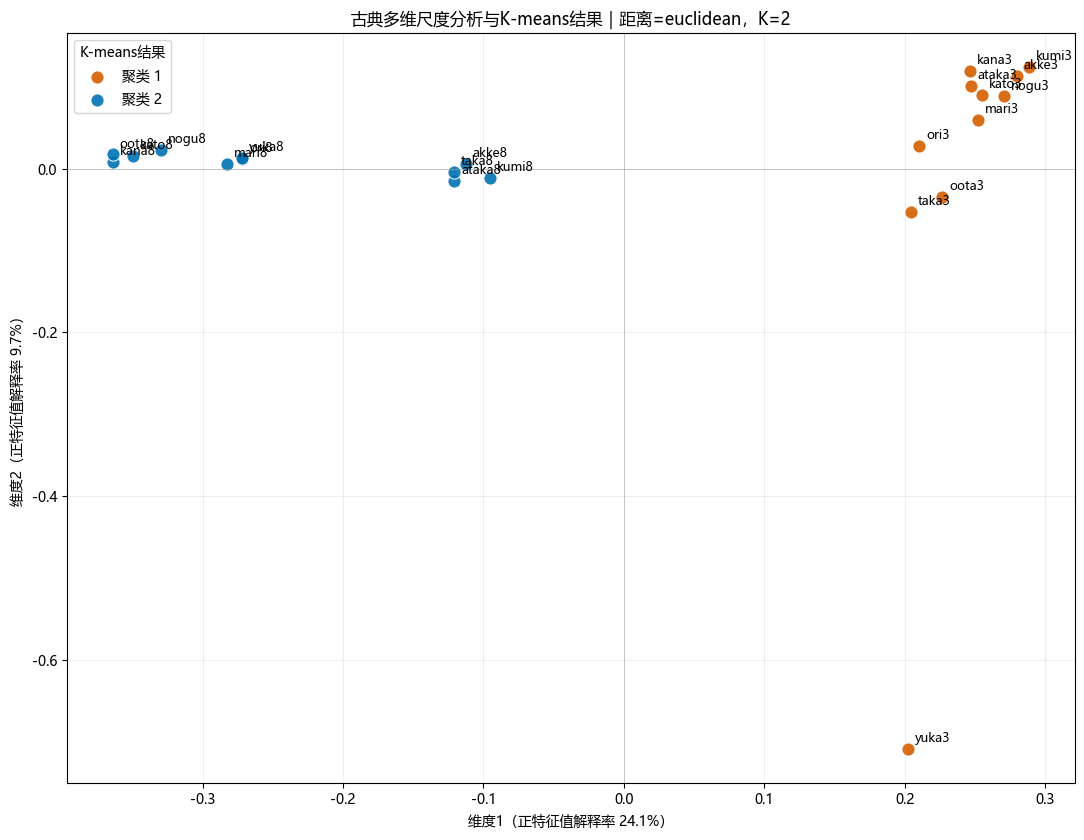

全部结果已保存至： C:\temp\kmeans_clustering_results
 - C:\temp\kmeans_clustering_results\classical_mds_kmeans.png
 - C:\temp\kmeans_clustering_results\classical_mds_coordinates.csv
 - C:\temp\kmeans_clustering_results\kmeans_cluster_assignments.csv
 - C:\temp\kmeans_clustering_results\kmeans_cluster_centers.csv
 - C:\temp\kmeans_clustering_results\kmeans_analysis_matrix.csv
 - C:\temp\kmeans_clustering_results\distance_matrix.csv
 - C:\temp\kmeans_clustering_results\matrix_count.csv
 - C:\temp\kmeans_clustering_results\matrix_relative.csv
 - C:\temp\kmeans_clustering_results\matrix_tfidf.csv
 - C:\temp\kmeans_clustering_results\tokenized_documents.csv
 - C:\temp\kmeans_clustering_results\vocabulary_statistics.csv
 - C:\temp\kmeans_clustering_results\run_parameters.json


In [50]:
input_dir = INPUT_DIR.expanduser().resolve()
output_dir = OUTPUT_DIR.expanduser().resolve()

if not input_dir.is_dir():
    raise FileNotFoundError("找不到输入文件夹：" + str(input_dir))
output_dir.mkdir(parents=True, exist_ok=True)

paths, texts = read_documents(collect_files(input_dir))
if len(paths) < 2:
    raise ValueError("K-means聚类至少需要两个文档。")
if not 2 <= N_CLUSTERS <= len(paths):
    raise ValueError("N_CLUSTERS必须在2和文档数之间。")

labels = make_unique_labels(paths)
tokenized, active_stopwords = tokenize_documents(texts)

(
    vocabulary, count_matrix, relative_matrix,
    tfidf_matrix, vocabulary_statistics
) = build_matrices(tokenized)

(
    analysis_matrix, distance_matrix,
    effective_matrix_name, feature_space_name
) = prepare_kmeans_space(relative_matrix, tfidf_matrix)

model, cluster_ids = run_kmeans(analysis_matrix)
coordinates, eigenvalues, explained = classical_mds(
    distance_matrix, dimensions=2
)
selected_font = choose_chinese_font()

count_df = pd.DataFrame(count_matrix, index=labels, columns=vocabulary)
relative_df = pd.DataFrame(
    relative_matrix, index=labels, columns=vocabulary
)
tfidf_df = pd.DataFrame(tfidf_matrix, index=labels, columns=vocabulary)
analysis_df = pd.DataFrame(
    analysis_matrix, index=labels, columns=vocabulary
)
distance_df = pd.DataFrame(
    distance_matrix, index=labels, columns=labels
)

assignment_df = pd.DataFrame({
    "聚类": cluster_ids.astype(int),
    "标签": labels,
    "文件名": [path.name for path in paths],
    "相对路径": [str(path.relative_to(input_dir)) for path in paths],
    "分词数": [len(tokens) for tokens in tokenized],
    "MDS维度1": coordinates[:, 0],
    "MDS维度2": coordinates[:, 1],
}).sort_values(["聚类", "标签"]).reset_index(drop=True)

mds_df = pd.DataFrame({
    "标签": labels,
    "聚类": cluster_ids.astype(int),
    "MDS维度1": coordinates[:, 0],
    "MDS维度2": coordinates[:, 1],
})
token_df = pd.DataFrame({
    "标签": labels,
    "文件名": [path.name for path in paths],
    "分词结果": [" ".join(tokens) for tokens in tokenized],
})
center_df = pd.DataFrame(
    model.cluster_centers_,
    index=[
        "聚类{}_中心".format(index + 1)
        for index in range(N_CLUSTERS)
    ],
    columns=vocabulary,
)

if 1 < len(set(cluster_ids)) < len(paths):
    silhouette = silhouette_score(
        distance_matrix, cluster_ids, metric="precomputed"
    )
else:
    silhouette = float("nan")

# 保存表格
count_df.to_csv(output_dir / "matrix_count.csv", encoding="utf-8-sig")
relative_df.to_csv(
    output_dir / "matrix_relative.csv", encoding="utf-8-sig"
)
tfidf_df.to_csv(
    output_dir / "matrix_tfidf.csv", encoding="utf-8-sig"
)
analysis_df.to_csv(
    output_dir / "kmeans_analysis_matrix.csv", encoding="utf-8-sig"
)
distance_df.to_csv(
    output_dir / "distance_matrix.csv", encoding="utf-8-sig"
)
assignment_df.to_csv(
    output_dir / "kmeans_cluster_assignments.csv",
    encoding="utf-8-sig", index=False
)
mds_df.to_csv(
    output_dir / "classical_mds_coordinates.csv",
    encoding="utf-8-sig", index=False
)
center_df.to_csv(
    output_dir / "kmeans_cluster_centers.csv",
    encoding="utf-8-sig"
)
token_df.to_csv(
    output_dir / "tokenized_documents.csv",
    encoding="utf-8-sig", index=False
)
vocabulary_statistics.to_csv(
    output_dir / "vocabulary_statistics.csv",
    encoding="utf-8-sig", index=False
)

parameters = {
    "输入文件夹": str(input_dir),
    "输出文件夹": str(output_dir),
    "文档数": len(paths),
    "筛选前N个高频变量": TOP_N_FEATURES,
    "实际变量数": len(vocabulary),
    "设置的数据矩阵": CLUSTER_MATRIX_TYPE,
    "K-means实际使用的数据矩阵": effective_matrix_name,
    "K-means数据空间": feature_space_name,
    "距离": KMEANS_DISTANCE,
    "聚类数": N_CLUSTERS,
    "初始化方法": KMEANS_INIT,
    "重复初始化次数": KMEANS_N_INIT,
    "最大迭代次数": KMEANS_MAX_ITER,
    "随机种子": RANDOM_STATE,
    "组内平方和": float(model.inertia_),
    "实际迭代次数": int(model.n_iter_),
    "轮廓系数": None if np.isnan(silhouette) else float(silhouette),
    "词性前缀": POS_PREFIXES,
    "停用词数": len(active_stopwords),
    "删除数字": REMOVE_DIGITS,
    "删除英文字母": REMOVE_LATIN,
    "同义词组": SYNONYM_GROUPS,
    "中文字体": selected_font,
}
(output_dir / "run_parameters.json").write_text(
    json.dumps(parameters, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

display(Markdown("### 运行条件"))
display(pd.DataFrame({
    "项目": [
        "文档数", "变量数", "设置的数据矩阵",
        "K-means实际使用的数据", "距离", "聚类数",
        "组内平方和", "轮廓系数", "保存位置"
    ],
    "设置值": [
        len(paths), len(vocabulary), CLUSTER_MATRIX_TYPE,
        "{}（{}）".format(effective_matrix_name, feature_space_name),
        KMEANS_DISTANCE, N_CLUSTERS,
        round(float(model.inertia_), 6),
        None if np.isnan(silhouette) else round(float(silhouette), 6),
        str(output_dir)
    ],
}))

display(Markdown("### 高频变量统计"))
display(vocabulary_statistics.head(TABLE_PREVIEW_ROWS))

display(Markdown("### 分词结果"))
display(token_df.head(TABLE_PREVIEW_ROWS))

display(Markdown(
    "### K-means实际使用的数据矩阵：{}（{}）".format(
        effective_matrix_name, feature_space_name
    )
))
display(
    analysis_df.iloc[
        :TABLE_PREVIEW_ROWS, :MATRIX_PREVIEW_SIZE
    ].round(5)
)

display(Markdown("### 各聚类的文档数"))
display(
    assignment_df.groupby("聚类").size()
    .rename("文档数").reset_index()
)

display(Markdown("### K-means聚类结果"))
display(assignment_df)

preview_size = min(MATRIX_PREVIEW_SIZE, len(labels))
display(Markdown("### 距离矩阵"))
display(
    distance_df.iloc[
        :preview_size, :preview_size
    ].round(5)
)

display(Markdown("### 古典多维尺度分析散点图"))
scatter_path = output_dir / "classical_mds_kmeans.png"
cluster_colors = draw_mds_scatter(
    coordinates, explained, labels,
    cluster_ids, scatter_path
)

print("全部结果已保存至：", output_dir)
for file_name in [
    "classical_mds_kmeans.png",
    "classical_mds_coordinates.csv",
    "kmeans_cluster_assignments.csv",
    "kmeans_cluster_centers.csv",
    "kmeans_analysis_matrix.csv",
    "distance_matrix.csv",
    "matrix_count.csv",
    "matrix_relative.csv",
    "matrix_tfidf.csv",
    "tokenized_documents.csv",
    "vocabulary_statistics.csv",
    "run_parameters.json",
]:
    print(" -", output_dir / file_name)
